# Modellvergleich: Seasonal-Naive vs. Prophet vs. Chronos-2 vs. TFT — PM2.5 Beijing

Vergleicht die vier Prognoseverfahren aus den Ausgangsnotebooks **fair auf denselben
Zeitfenstern**:

- **Seasonal-Naive-Baseline** (aus `04_TFT_Modelle_vergleichen.ipynb`) — Vorjahreswert, exakt
  364 Tage (52 Wochen) zurück, dadurch automatisch gleicher Wochentag/gleiche Uhrzeit.
- **Prophet** (Meta) — additives, statistisches Zeitreihenmodell (Trend + tägliche/wöchentliche/
  jährliche Saisonalität + Feiertage + Wetter-Regressoren). Wird **pro Fenster neu** auf der
  gesamten Historie davor gefittet; in zwei Wetter-Varianten (Perfect-Prognosis + Persistenz,
  siehe Abschnitt 7b).
- **Chronos-2** (aus `SpaeterLoeschen_Modellierung_Chronos2_..._v9.ipynb`) — hier bewusst **ohne
  die räumlichen Kovariaten aus Abschnitt 6b** (kein Windaufwärts-Regressor), die
  Chronos-Konfiguration (Datenvariante, Regressoren, Feiertage, Log) bleibt aber frei anpassbar,
  analog zur Konfigurationsleiter (Zelle 23/24) im Ausgangsnotebook.
- **TFT** (aus `04_TFT_Modelle_vergleichen.ipynb`) — bereits trainiertes, gespeichertes Modell,
  wird hier nur geladen und für Inferenz genutzt (kein erneutes Training).

Zwei Vergleichsarten, beide für **`HORIZONTE = [8, 24, 48, 72]` Stunden**:

1. **Variables Split-Datum** (Abschnitt 8): ein frei wählbares `SPLIT_DATUM`, Plot + Fehlertabelle
   je Station, mit allen Modellen in derselben Abbildung.
2. **Rolling-Window-Backtest** (Abschnitt 9): Zeitraum **01.09.2016 – 28.02.2017**, Versatz
   zwischen den Fenstern frei wählbar (Default **15 Tage**) — für die **zuletzt gewählte
   Chronos-Konfiguration**.

> ℹ️ **Stationen:** Der Rolling-Vergleich (Abschnitt 9) läuft über **alle 12 Stationen**
> (`STATIONEN_VERGLEICH = ALLE_STATIONEN`). Die Einzel-Split-Plots (Abschnitt 8) nutzen
> `STATIONEN_DETAIL` (Default ebenfalls alle 12; zum Zeitsparen auf eine Teilliste setzbar).
> Beide Listen in der Konfigurationszelle (Abschnitt 2) frei anpassbar.

> ⚠️ **Chronos-Auflösung bewusst auf stündlich gestellt** (`AGG_STUNDEN_CHRONOS = 1`), abweichend
> vom 4h-Default im Ausgangsnotebook: TFT und die Naive-Baseline rechnen beide stündlich — nur so
> sind die Modelle auf denselben Zeitstempeln direkt vergleichbar. Bei Bedarf in der
> Konfiguration änderbar, dann werden Chronos-Vorhersagen aber auf einem gröberen Raster liegen
> und beim Merge mit TFT/Naive nur die gemeinsamen Zeitstempel verglichen.

> 📊 **In allen Abbildungen wird Chronos-2 zusätzlich in der 4h-Aggregation eingezeichnet**
> (`AGG_STUNDEN_CHRONOS_ZUSATZ = 4`, Konfiguration Abschnitt 2) — als eigene, hellere Kurve mit
> Markern und nur an den tatsächlich vorhandenen 4h-Zeitpunkten (kein Auffüllen aufs
> Stundenraster). Seasonal-Naive, TFT und die 1h-Chronos-Variante werden dagegen immer auf dem
> vollen Stundenraster gezeichnet. Diese 4h-Zusatzkurve fließt **nicht** in die Fehlertabellen
> (MAE/RMSE/MASE/MAPE) ein, da deren stündliche MASE-Skalen nicht direkt auf ein gröberes
> Raster übertragbar sind — sie dient ausschließlich der visuellen Einordnung.

## 1. Bibliotheken & Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import holidays

import chronos
from chronos import Chronos2Pipeline
from sklearn.preprocessing import StandardScaler
from neuralforecast import NeuralForecast

torch.set_float32_matmul_precision("high")

print("chronos-forecasting-Version:", chronos.__version__)
print("torch-Version:             ", torch.__version__, "| CUDA verfuegbar:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 72, "axes.titlesize": 13, "axes.titleweight": "bold"})
AMBER, RUST, SLATE, TEAL, MOSS = "#E0912F", "#C4471C", "#3A4148", "#1C7293", "#2C5F2D"
CHRONOSFARBE = "#7B2CBF"      # Chronos-2, 1h-Aufloesung (violett, wie im Chronos-Notebook)
CHRONOSFARBE_4H = "#C9A2E8"   # Chronos-2, 4h-Aufloesung (helleres Violett -- immer zusaetzlich gezeigt)
PROPHETFARBE      = "#1f6feb"  # Prophet, Perfect-Prognosis (kraeftiges Blau)
PROPHETFARBE_PERS = "#7FB3FF"  # Prophet, Persistenz-Wetter (helleres Blau)
FARBEN_MODELLE = {"Seasonal Naive": AMBER, "Chronos-2": CHRONOSFARBE,
                  "Chronos-2 (4h)": CHRONOSFARBE_4H, "TFT": MOSS,
                  "Prophet (PP)": PROPHETFARBE, "Prophet (Pers.)": PROPHETFARBE_PERS}
MODELL_ORDER = ["Seasonal Naive", "Prophet (Pers.)", "Prophet (PP)", "Chronos-2", "TFT"]  # Anzeige-Reihenfolge

chronos-forecasting-Version: 2.3.1
torch-Version:              2.6.0+cu124 | CUDA verfuegbar: True


## 2. Konfiguration

Alles Konfigurierbare an einem Ort.

In [2]:
# --- Pfade -------------------------------------------------------------------------------------
PREP        = Path("../data/prepared_chronos")             # fuer Chronos-2 (variante = "basis"/"behandelt")
TFT_DATA_DIR = PREP / "behandelt"                            # TFT wurde ausschliesslich auf "behandelt" trainiert
MODELL_DIR  = Path("../models/tft_final_multivariat_v8_v6")   # TFT v3 (neu trainiert, aus Notebook 03) -- vorher: ..._v2

FREQ = "h"          # stuendliche Basisaufloesung fuer beide Modelle
HORIZONTE = [8, 24, 48, 72]
H_MAX = max(HORIZONTE)

# --- Stationen -----------------------------------------------------------------------------------
ALLE_STATIONEN = sorted(p.name.replace("chronos_", "").replace(".csv", "")
                        for p in TFT_DATA_DIR.glob("chronos_*.csv"))

# Annahme (siehe Hinweis oben) -- frei anpassbar, beide Eintraege muessen in ALLE_STATIONEN stehen:
STATIONEN_VERGLEICH = ALLE_STATIONEN   # alle 12 Stationen; mit 15-Tage-Versatz ~1,5-2 h (Prophet-dominiert)
assert set(STATIONEN_VERGLEICH) <= set(ALLE_STATIONEN), \
    f"Unbekannte Station(en) in STATIONEN_VERGLEICH -- verfuegbar: {ALLE_STATIONEN}"
print(f"Stationen im Vergleich: {STATIONEN_VERGLEICH}")

# Stationen fuer die Einzel-Split-Plots in Abschnitt 8 (hier alle 12; zum Zeitsparen auf eine Teilliste setzen):
STATIONEN_DETAIL = ALLE_STATIONEN
assert set(STATIONEN_DETAIL) <= set(ALLE_STATIONEN), "STATIONEN_DETAIL nicht in ALLE_STATIONEN"

STATIONSTYP_TEXT = {
    "Changping": "Vorstadt/Hintergrund", "Dingling": "Vorstadt/Hintergrund", "Dongsi": "Urban",
    "Guanyuan": "Urban", "Gucheng": "Urban/Industrienah", "Huairou": "Vorstadt/Hintergrund",
    "Nongzhanguan": "Urban", "Shunyi": "Vorstadt", "Tiantan": "Urban/Park", "Wanliu": "Urban",
    "Wanshouxigong": "Urban", "Aotizhongxin": "Urban",
}
STATIONSTYP_CODE = {"Urban": 0, "Urban/Park": 0, "Urban/Industrienah": 0,
                    "Vorstadt/Hintergrund": 1, "Vorstadt": 1}

# --- Variables Split-Datum (Abschnitt 8) ----------------------------------------------------------
SPLIT_DATUM = "2016-12-15"

# --- Rolling-Window-Backtest (Abschnitt 9) --------------------------------------------------------
ROLLING_START        = "2016-09-01"
ROLLING_ENDE          = "2017-02-28"
ROLLING_SCHRITT_TAGE  = 15          # frei anpassbarer Versatz zwischen den Fenstern

# --- TFT: MUSS zum geladenen Modell passen (siehe 04_TFT_Modelle_vergleichen.ipynb) ---------------
TRAIN_CUTOFF  = "2016-08-30"
INPUT_SIZE    = 336
WETTER_REGRESSOREN        = ["TEMP", "DEWP", "PRES", "WSPM", "RAIN", "wd_sin", "wd_cos"]
KALENDER_REGRESSOREN      = ["hour_sin", "hour_cos", "day_sin", "day_cos", "feiertag"]
REGRESSOREN_ZUKUNFT_TFT   = WETTER_REGRESSOREN + KALENDER_REGRESSOREN
REGRESSOREN_VERGANGENHEIT_TFT = ["SO2", "NO2", "CO", "O3"]
REGRESSOREN_ZU_SKALIEREN  = WETTER_REGRESSOREN[:-2] + REGRESSOREN_VERGANGENHEIT_TFT

# --- Chronos-2: Regressoren-Pool (fuer die Konfiguration in Abschnitt 6) ---------------------------
REGRESSOREN_ZUKUNFT_CHRONOS       = ["TEMP", "DEWP", "PRES", "WSPM", "RAIN", "wd_sin", "wd_cos",
                                     "tage_seit_cny", "cny_naehe", "jahr_sin", "jahr_cos"]
REGRESSOREN_VERGANGENHEIT_CHRONOS = ["SO2", "NO2", "CO", "O3"]
AGG_STUNDEN_CHRONOS = 1   # siehe Hinweis oben -- stuendlich, damit direkt mit TFT/Naive vergleichbar
AGG_STUNDEN_CHRONOS_ZUSATZ = 4   # wird in allen Abbildungen IMMER zusaetzlich zur 1h-Variante gezeigt
                                  # (nur die tatsaechlich vorhandenen 4h-Punkte -- kein Auffuellen
                                  # aufs Stundenraster); geht NICHT in die Fehlertabellen ein.

print(f"Horizonte: {HORIZONTE} h | Split-Datum: {SPLIT_DATUM}")
print(f"Rolling-Window: {ROLLING_START} -- {ROLLING_ENDE}, Versatz {ROLLING_SCHRITT_TAGE} Tage")

Stationen im Vergleich: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
Horizonte: [8, 24, 48, 72] h | Split-Datum: 2016-12-15
Rolling-Window: 2016-09-01 -- 2017-02-28, Versatz 15 Tage


## 3. Gemeinsame Hilfsfunktionen: Split, Fehlermaße, Regularisierung

In [3]:
def split_bei(df, split_datum):
    '''Teilt eine durchgehende Zeitreihe an split_datum in (train, test); test beginnt AB
    (einschliesslich) split_datum.'''
    grenze = pd.Timestamp(split_datum)
    train = df[df["ds"] <  grenze].reset_index(drop=True)
    test  = df[df["ds"] >= grenze].reset_index(drop=True)
    return train, test


def mae(y, yhat):  return float(np.mean(np.abs(np.asarray(y, float) - np.asarray(yhat, float))))
def rmse(y, yhat): return float(np.sqrt(np.mean((np.asarray(y, float) - np.asarray(yhat, float)) ** 2)))
def mape(y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float); m = y > 0
    return float(np.mean(np.abs((y[m] - yhat[m]) / y[m])) * 100) if m.any() else np.nan

def mase_skala(train_y, m=24):
    a = np.asarray(train_y, dtype=float)
    return float(np.nanmean(np.abs(a[m:] - a[:-m])))

def mase(y, yhat, skala): return float(mae(y, yhat) / skala)

def fehlermasse(y, yhat, skala):
    return {"MAE": mae(y, yhat), "RMSE": rmse(y, yhat), "MASE": mase(y, yhat, skala), "MAPE %": mape(y, yhat)}


def fehlertabelle_horizonte(vergleich, y_spalte, yhat_spalten_je_modell, skala_je_modell,
                            horizonte=HORIZONTE, lead_spalte="lead"):
    '''Fehlermasse je Modell (aus `yhat_spalten_je_modell`, {modellname: spaltenname}) UND je
    Horizont (kumulativ ab Fensterbeginn, ueber `lead_spalte` in Stunden) -- ein DataFrame mit
    Spalten Horizont/Modell/MAE/RMSE/MASE/MAPE %.'''
    zeilen = []
    for b in horizonte:
        w = vergleich[vergleich[lead_spalte] <= b]
        for modell, yhat_spalte in yhat_spalten_je_modell.items():
            zeilen.append({"Horizont": f"{b} h", "Modell": modell,
                           **fehlermasse(w[y_spalte], w[yhat_spalte], skala_je_modell[modell])})
    return pd.DataFrame(zeilen)


def regularize(df, spalten, freq=FREQ):
    '''Bringt einen Frame auf ein luecken-freies Stundenraster; numerische Spalten linear
    interpoliert. Fuer Chronos UND TFT gemeinsam nutzbar (identische Logik in beiden
    Ausgangsnotebooks).'''
    d = df.set_index("ds").sort_index()
    voll = pd.date_range(d.index.min(), d.index.max(), freq=freq)
    d = d.reindex(voll)
    for c in spalten:
        d[c] = d[c].interpolate(limit_direction="both")
    d.index.name = "ds"
    return d.reset_index()


def aggregiere(df, stunden, spalten):
    '''Aggregiert einen luecken-freien Stundenframe auf `stunden`-Stunden-Bins (Mittelwert).'''
    d = df.set_index("ds").sort_index()
    agg = d[spalten].resample(f"{stunden}h").mean()
    agg.index.name = "ds"
    return agg.reset_index()


_CN_HOLIDAYS = holidays.country_holidays("CN", years=range(2013, 2018))

def add_feiertag(df):
    d = df.copy()
    d["feiertag"] = d["ds"].dt.date.astype("O").map(lambda t: 1 if t in _CN_HOLIDAYS else 0)
    return d

## 4. Chronos-2: Pipeline laden

In [4]:
chronos_pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE)
print("Chronos-2 geladen auf:", DEVICE)

Chronos-2 geladen auf: cuda


## 5. Chronos-2: Daten laden & Vorhersagefunktion

Identisch zum Ausgangsnotebook (Abschnitt 2/2b/6), aber **ohne** die räumlichen Kovariaten aus
Abschnitt 6b (kein Windaufwärts-Regressor). `chronos_lade_gesamt()` lädt eine Station als
durchgehende Zeitreihe (inkl. der kalenderbasierten Saisonalitäts-Kovariaten `tage_seit_cny`,
`cny_naehe`, `jahr_sin`, `jahr_cos`); `chronos_predict()`/`chronos_predict_fenster()` sind die
Kernfunktionen für ein variables bzw. ein auf `horizont_stunden` begrenztes Fenster.

In [5]:
_CNY_KALENDER = holidays.country_holidays("CN", years=range(2012, 2019))
_CNY_NACH_JAHR = {}
for _datum, _name in _CNY_KALENDER.items():
    if "\u6625\u8282" in _name:   # 春节 = Chinesisches Neujahr
        _CNY_NACH_JAHR.setdefault(_datum.year, []).append(_datum)
CNY_TERMINE = {jahr: min(daten) for jahr, daten in _CNY_NACH_JAHR.items()}
_CNY_SORTIERT = np.array(sorted(pd.Timestamp(d) for d in CNY_TERMINE.values()), dtype="datetime64[ns]")


def add_saison_kovariaten(df, cny_sigma_tage=6.0):
    '''Vier deterministische, kalenderbasierte Kovariaten (alle im Voraus bekannt): tage_seit_cny,
    cny_naehe (Gauss-Bump um CNY), jahr_sin/jahr_cos (zyklische Kodierung des Tags im Jahr).'''
    d = df.copy()
    ds_arr = d["ds"].values.astype("datetime64[ns]")
    idx_hi = np.clip(np.searchsorted(_CNY_SORTIERT, ds_arr), 0, len(_CNY_SORTIERT) - 1)
    idx_lo = np.clip(idx_hi - 1, 0, len(_CNY_SORTIERT) - 1)
    diff_hi = (_CNY_SORTIERT[idx_hi] - ds_arr) / np.timedelta64(1, "D")
    diff_lo = (ds_arr - _CNY_SORTIERT[idx_lo]) / np.timedelta64(1, "D")
    naeher_ist_hi = diff_hi < diff_lo
    tage_seit_cny = np.where(naeher_ist_hi, -diff_hi, diff_lo)
    d["tage_seit_cny"] = tage_seit_cny
    d["cny_naehe"] = np.exp(-0.5 * (tage_seit_cny / cny_sigma_tage) ** 2)
    doy = d["ds"].dt.dayofyear.to_numpy()
    d["jahr_sin"] = np.sin(2 * np.pi * doy / 365.25)
    d["jahr_cos"] = np.cos(2 * np.pi * doy / 365.25)
    return d


_chronos_gesamt_cache = {}

def chronos_lade_gesamt(station, variante):
    '''variante = "basis" oder "behandelt". Cacht pro (station, variante), da im Rolling-Window-
    Backtest wiederholt dieselbe Kombination geladen wird.'''
    key = (station, variante)
    if key not in _chronos_gesamt_cache:
        df = pd.read_csv(PREP / variante / f"chronos_{station}.csv", parse_dates=["ds"])
        df = df.sort_values("ds").reset_index(drop=True)
        _chronos_gesamt_cache[key] = add_saison_kovariaten(df)
    return _chronos_gesamt_cache[key]


def chronos_predict(gesamt, split_datum, regressoren_zukunft=None, regressoren_vergangenheit=None,
                    feiertag=False, log=False, agg_stunden=AGG_STUNDEN_CHRONOS, station=None):
    '''Wie im Ausgangsnotebook (Abschnitt 6): Vorhersage von split_datum bis zum Ende der
    verfuegbaren Daten.'''
    regressoren_zukunft = regressoren_zukunft or []
    regressoren_vergangenheit = regressoren_vergangenheit or []
    alle_regressoren = list(regressoren_zukunft) + list(regressoren_vergangenheit)

    g = regularize(gesamt, spalten=["y"] + alle_regressoren)
    freq_akt = FREQ
    if agg_stunden and agg_stunden > 1:
        g = aggregiere(g, agg_stunden, spalten=["y"] + alle_regressoren)
        freq_akt = f"{agg_stunden}h"
    tr, te = split_bei(g, split_datum)

    if feiertag:
        tr, te = add_feiertag(tr), add_feiertag(te)
    zukunft_kov = list(regressoren_zukunft) + (["feiertag"] if feiertag else [])
    alle_kov    = alle_regressoren + (["feiertag"] if feiertag else [])

    tr_c = tr.copy()
    if log:
        tr_c["y"] = np.log1p(tr_c["y"])
    context_df = tr_c[["ds", "y"] + alle_kov].rename(columns={"y": "target"}).copy()
    context_df["id"] = station
    future_df = None
    if zukunft_kov:
        future_df = te[["ds"] + zukunft_kov].copy()
        future_df["id"] = station

    pred_df = chronos_pipeline.predict_df(
        context_df, future_df=future_df, prediction_length=len(te),
        quantile_levels=[0.1, 0.5, 0.9], id_column="id", timestamp_column="ds", target="target",
        freq=freq_akt,
    )
    rueck = (lambda a: np.expm1(a)) if log else (lambda a: a)
    pred_df = pred_df.rename(columns={"0.5": "yhat", "0.1": "yhat_lower", "0.9": "yhat_upper"})
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        pred_df[c] = rueck(pred_df[c])

    _, test_original = split_bei(gesamt, split_datum)
    test_eval = test_original
    if agg_stunden and agg_stunden > 1:
        test_eval = (test_original.set_index("ds")[["y"]].resample(f"{agg_stunden}h").mean()
                          .dropna().rename_axis("ds").reset_index())
    out = test_eval[["ds", "y"]].merge(pred_df[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        out[c] = out[c].clip(lower=0)
    return out


def chronos_predict_fenster(gesamt, fold_start, horizont_stunden, regressoren_zukunft=None,
                            regressoren_vergangenheit=None, feiertag=False, log=False,
                            agg_stunden=AGG_STUNDEN_CHRONOS, station=None):
    '''Wie chronos_predict(), aber auf ein festes horizont_stunden-Fenster begrenzt -- fuer den
    Rolling-Window-Backtest (Abschnitt 9).'''
    regressoren_zukunft = regressoren_zukunft or []
    regressoren_vergangenheit = regressoren_vergangenheit or []
    alle_regressoren = list(regressoren_zukunft) + list(regressoren_vergangenheit)

    g = regularize(gesamt, spalten=["y"] + alle_regressoren)
    freq_akt = FREQ
    if agg_stunden and agg_stunden > 1:
        g = aggregiere(g, agg_stunden, spalten=["y"] + alle_regressoren)
        freq_akt = f"{agg_stunden}h"
    tr, te = split_bei(g, fold_start)
    fold_ende = pd.Timestamp(fold_start) + pd.Timedelta(hours=horizont_stunden)
    te = te[te["ds"] < fold_ende].reset_index(drop=True)

    if feiertag:
        tr, te = add_feiertag(tr), add_feiertag(te)
    zukunft_kov = list(regressoren_zukunft) + (["feiertag"] if feiertag else [])
    alle_kov    = alle_regressoren + (["feiertag"] if feiertag else [])

    tr_c = tr.copy()
    if log:
        tr_c["y"] = np.log1p(tr_c["y"])
    context_df = tr_c[["ds", "y"] + alle_kov].rename(columns={"y": "target"}).copy()
    context_df["id"] = station
    future_df = None
    if zukunft_kov:
        future_df = te[["ds"] + zukunft_kov].copy()
        future_df["id"] = station

    pred_df = chronos_pipeline.predict_df(
        context_df, future_df=future_df, prediction_length=len(te),
        quantile_levels=[0.1, 0.5, 0.9], id_column="id", timestamp_column="ds", target="target",
        freq=freq_akt,
    )
    rueck = (lambda a: np.expm1(a)) if log else (lambda a: a)
    pred_df = pred_df.rename(columns={"0.5": "yhat", "0.1": "yhat_lower", "0.9": "yhat_upper"})
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        pred_df[c] = rueck(pred_df[c])

    _, test_original = split_bei(gesamt, fold_start)
    test_original = test_original[test_original["ds"] < fold_ende]
    test_eval = test_original
    if agg_stunden and agg_stunden > 1:
        test_eval = (test_original.set_index("ds")[["y"]].resample(f"{agg_stunden}h").mean()
                          .dropna().rename_axis("ds").reset_index())
    out = test_eval[["ds", "y"]].merge(pred_df[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        out[c] = out[c].clip(lower=0)
    return out

## 6. Chronos-Konfiguration (frei anpassbar)

Entspricht der Konfigurationsleiter im Ausgangsnotebook (Zelle 23/24: `konfigs_chronos`) — hier
aber als **eine** aktive, direkt änderbare Konfiguration statt einer ganzen Leiter. `variante`
bestimmt die Datengrundlage (`"basis"` oder `"behandelt"`), die Regressorlisten werden aus dem
Pool in der Konfiguration (Abschnitt 2) gewählt.

**Diese Zelle ist die zentrale Stellschraube für die Abschnitte 8 und 9** — einfach anpassen und
die nachfolgenden Zellen neu ausführen, um eine andere Konfiguration zu testen.

In [6]:
CHRONOS_KONFIG = dict(
    variante                   = "behandelt",
    regressoren_zukunft        = REGRESSOREN_ZUKUNFT_CHRONOS,
    regressoren_vergangenheit  = REGRESSOREN_VERGANGENHEIT_CHRONOS,
    feiertag                   = True,
    log                        = True,
)

print("Aktive Chronos-Konfiguration:")
for k, v in CHRONOS_KONFIG.items():
    print(f"  {k}: {v}")

Aktive Chronos-Konfiguration:
  variante: behandelt
  regressoren_zukunft: ['TEMP', 'DEWP', 'PRES', 'WSPM', 'RAIN', 'wd_sin', 'wd_cos', 'tage_seit_cny', 'cny_naehe', 'jahr_sin', 'jahr_cos']
  regressoren_vergangenheit: ['SO2', 'NO2', 'CO', 'O3']
  feiertag: True
  log: True


## 7. TFT: Daten laden & Modell laden

Übernommen aus `04_TFT_Modelle_vergleichen.ipynb` (Abschnitt 1–3) — hier auf
`STATIONEN_VERGLEICH` beschränkt statt auf alle Trainingsstationen (das trainierte Modell selbst
bleibt unverändert, es wird nur für weniger Stationen Inferenz gemacht).

In [7]:
stat_df_tft = pd.DataFrame({
    "unique_id": STATIONEN_VERGLEICH,
    "stationstyp": [float(STATIONSTYP_CODE[STATIONSTYP_TEXT[s]]) for s in STATIONEN_VERGLEICH],
})

def add_time_features(df):
    d = df.copy()
    d["hour_sin"] = np.sin(2*np.pi*d["ds"].dt.hour/24); d["hour_cos"] = np.cos(2*np.pi*d["ds"].dt.hour/24)
    d["day_sin"]  = np.sin(2*np.pi*d["ds"].dt.dayofyear/365.25); d["day_cos"] = np.cos(2*np.pi*d["ds"].dt.dayofyear/365.25)
    return d

alle_spalten_tft = ["y"] + WETTER_REGRESSOREN + REGRESSOREN_VERGANGENHEIT_TFT

teile_tft, skalen_tft, letzte_ds_tft = [], {}, []
for st in STATIONEN_VERGLEICH:
    d = pd.read_csv(TFT_DATA_DIR / f"chronos_{st}.csv", parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
    d = regularize(d, spalten=alle_spalten_tft)
    d = add_time_features(d)
    d = add_feiertag(d)
    d = d[["ds"] + alle_spalten_tft + KALENDER_REGRESSOREN].copy()
    d.insert(0, "unique_id", st)

    train_maske = d["ds"] < pd.Timestamp(TRAIN_CUTOFF)
    skalen_tft[st] = mase_skala(d.loc[train_maske, "y"], m=24)
    letzte_ds_tft.append(d["ds"].max())
    teile_tft.append(d)

multi_tft = pd.concat(teile_tft, ignore_index=True)
DATENENDE_TFT = min(letzte_ds_tft)
multi_tft = multi_tft[multi_tft["ds"] <= DATENENDE_TFT].reset_index(drop=True)

multi_tft["y_original"] = multi_tft["y"]
multi_tft["y"] = np.log1p(multi_tft["y"])

train_maske = multi_tft["ds"] < pd.Timestamp(TRAIN_CUTOFF)
scaler_tft = StandardScaler()
scaler_tft.fit(multi_tft.loc[train_maske, REGRESSOREN_ZU_SKALIEREN])
multi_tft[REGRESSOREN_ZU_SKALIEREN] = scaler_tft.transform(multi_tft[REGRESSOREN_ZU_SKALIEREN])

print(f"TFT-Daten geladen fuer {STATIONEN_VERGLEICH}, Datenende: {DATENENDE_TFT}")
print("MASE-Skalen (TFT/Naive, stuendlich, m=24):", {k: round(v, 2) for k, v in skalen_tft.items()})

TFT-Daten geladen fuer ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong'], Datenende: 2017-02-28 23:00:00
MASE-Skalen (TFT/Naive, stuendlich, m=24): {'Aotizhongxin': 57.51, 'Changping': 51.41, 'Dingling': 51.17, 'Dongsi': 60.66, 'Guanyuan': 56.72, 'Gucheng': 56.97, 'Huairou': 50.17, 'Nongzhanguan': 60.82, 'Shunyi': 57.71, 'Tiantan': 57.42, 'Wanliu': 57.93, 'Wanshouxigong': 60.39}


In [8]:
def seasonal_naive_vorhersage(multi, station, ziel_ds, tage_zurueck=364):
    '''Seasonal-Naive-Baseline (aus 04_TFT_Modelle_vergleichen.ipynb): Prognose = beobachteter
    Wert (`y_original`) exakt `tage_zurueck` Tage zuvor. Default 364 statt 365 Tage, damit der
    Referenzzeitpunkt automatisch auf denselben Wochentag/dieselbe Uhrzeit faellt.'''
    hist = multi.loc[multi["unique_id"] == station].set_index("ds")["y_original"]
    lag = pd.Timedelta(days=tage_zurueck)
    vorhersagen = np.array([hist.get(ds - lag, np.nan) for ds in ziel_ds])
    if np.isnan(vorhersagen).any():
        print(f"Hinweis: Fuer {np.isnan(vorhersagen).sum()} Zeitpunkt(e) lag kein Wert von vor "
             f"{tage_zurueck} Tagen vor (vermutlich Datenbeginn zu nah dran).")
    return vorhersagen

In [9]:
assert MODELL_DIR.exists(), f"Modell-Ordner {MODELL_DIR} nicht gefunden -- Pfad oben pruefen."

nf = NeuralForecast.load(path=str(MODELL_DIR))

if not torch.cuda.is_available():
    print("Keine GPU gefunden -- Inferenz laeuft auf CPU.")
    for model in nf.models:
        model.trainer_kwargs["accelerator"] = "cpu"
        model.trainer_kwargs["devices"] = 1
else:
    print("GPU gefunden -- Inferenz laeuft auf GPU.")

print(f"TFT-Modell geladen aus: {MODELL_DIR}")

Seed set to 1


GPU gefunden -- Inferenz laeuft auf GPU.
TFT-Modell geladen aus: ..\models\tft_final_multivariat_v8_v6


## 7b. Prophet: Vorhersagefunktion

**Grundidee.** Prophet (Meta) zerlegt eine Zeitreihe *additiv* in interpretierbare Komponenten:

`y(t) = Trend(t) + Saisonalität(t) + Feiertage(t) + Σ βᵢ · Regressorᵢ(t) + Rest`

Hier aktiv: stückweise-linearer **Trend**, **tägliche + wöchentliche + jährliche Saisonalität** (Fourier-Terme), **chinesische Feiertage** (`add_country_holidays("CN")`) und die **Wetter-Regressoren** (`TEMP, DEWP, PRES, WSPM, RAIN, wd_sin, wd_cos`) als lineare Zusatzterme. Die Zielgröße wird **log1p**-transformiert (PM2.5 ist positiv und rechtsschief), die Vorhersage zurücktransformiert und bei 0 abgeschnitten.

**Einsatz hier.** Prophet wird **pro Fold neu** auf allen Daten *vor* `fold_start` trainiert (expandierendes Fenster) — im Gegensatz zum *eingefrorenen* TFT und zum *zero-shot* Chronos-2. Gleiche Datenbasis (`behandelt`, stündlich) und dieselbe feste, stündliche MASE-Skala wie TFT/Naive, damit alle Modelle direkt vergleichbar sind.

**Zwei Wetter-Varianten** — sie zeigen, wie stark das Ergebnis von der Wetterprognose abhängt:

- **Prophet (PP) – Perfect-Prognosis:** der Prognosezeitraum bekommt die *tatsächlichen* zukünftigen Wetterwerte. Optimistische Obergrenze und faire Augenhöhe mit TFT/Chronos, die ebenfalls zukünftige Wetter-Regressoren nutzen.
- **Prophet (Pers.) – Persistenz:** das Wetter wird ab `fold_start` auf dem letzten bekannten Wert eingefroren (realistischer Betrieb). Der Abstand *PP → Pers.* ist der „Preis dafür, das Wetter nicht zu kennen".

**Was Prophet von den anderen Ansätzen unterscheidet** (Kern dieses Vergleichs):

| | Prophet | Chronos-2 | TFT |
|---|---|---|---|
| Typ | klassisch-statistisch, additiv | Transformer-Foundation-Modell | tiefes neuronales Netz |
| Training | **pro Fenster neu** gefittet | zero-shot (kein Training) | einmal global trainiert, eingefroren |
| Modell je … | Station | Station (eigener Kontext) | ein globales Modell für alle |
| Stärke | interpretierbar, robust bei glatten/saisonalen Reihen | starke Muster ohne Training | komplexe, nichtlineare Zusammenhänge |
| Schwäche | lineare Regressoren, verpasst kurze Extreme (Neujahrsfest) | Blackbox, begrenzte Kontextlänge | Trainingsaufwand, Blackbox |
| Laufzeit | **hoch** (Refit je Fold/Station) | gering (GPU-Inferenz) | sehr gering (nur Inferenz) |

> Die Feiertags-Komponente ist genau der Mechanismus, mit dem Prophet das chinesische Neujahr greifen *könnte* — aber ein fester, jährlich gleicher Offset kann den kurzen, stark schwankenden Feuerwerks-Peak nicht nachbilden. Deshalb scheitern hier alle Modelle am Neujahrsfest.

In [10]:
from prophet import Prophet
import logging as _logging
_logging.getLogger("prophet").setLevel(_logging.ERROR)
_logging.getLogger("cmdstanpy").setLevel(_logging.ERROR)

PROPHET_REGRESSOREN = WETTER_REGRESSOREN   # TEMP, DEWP, PRES, WSPM, RAIN, wd_sin, wd_cos (zukunftsbekannt)

def _prophet_daten(station, variante="behandelt"):
    """Laedt die (fuer Chronos vorbereiteten) Stationsdaten und regularisiert sie stuendlich --
    dieselbe Datenbasis wie Chronos/TFT."""
    df = pd.read_csv(PREP / variante / f"chronos_{station}.csv", parse_dates=["ds"])
    df = df.sort_values("ds").reset_index(drop=True)
    return regularize(df, spalten=["y"] + PROPHET_REGRESSOREN)

def prophet_predict_fenster(station, fold_start, horizont=H_MAX, wetter="perfect", log=True, variante="behandelt"):
    """Prophet-Prognose (Perfect-Prognosis) fuer `station` ab `fold_start` ueber `horizont` Stunden.
    Rueckgabe: DataFrame mit Spalten ds/yhat_prophet auf dem Stundenraster (direkt mit TFT/Naive
    mergebar). Prophet wird pro Aufruf neu auf allen Daten vor fold_start trainiert.
    wetter="perfect": tatsaechliche zukuenftige Wetterwerte (Obergrenze). wetter="persistenz":
    letzter bekannter Wetterwert konstant fortgeschrieben (realistischer Betrieb)."""
    fold_start = pd.Timestamp(fold_start)
    g = _prophet_daten(station, variante)
    tr, te = split_bei(g, fold_start)
    te = te[te["ds"] < fold_start + pd.Timedelta(hours=horizont)].reset_index(drop=True)
    if wetter == "persistenz":
        # Realistischer Betrieb: zukuenftiges Wetter = letzter beobachteter Wert (konstant fortgeschrieben).
        letzte = tr[PROPHET_REGRESSOREN].iloc[-1]
        for r in PROPHET_REGRESSOREN:
            te[r] = letzte[r]
    trc = tr[["ds", "y"] + PROPHET_REGRESSOREN].copy()
    if log:
        trc["y"] = np.log1p(trc["y"])
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
    m.add_country_holidays(country_name="CN")
    for r in PROPHET_REGRESSOREN:
        m.add_regressor(r)
    m.fit(trc)
    fc = m.predict(te[["ds"] + PROPHET_REGRESSOREN])
    yhat = np.expm1(fc["yhat"].values) if log else fc["yhat"].values
    out = te[["ds", "y"]].copy()
    out["yhat_prophet"] = np.clip(yhat, 0, None)
    return out[["ds", "yhat_prophet"]]

print("Prophet-Vorhersagefunktion bereit -- zwei Wetter-Modi: perfect | persistenz.")
print("Hinweis: Prophet wird pro Fold neu trainiert -- rechne mit ~15-30 s pro Station/Fold.")

Importing plotly failed. Interactive plots will not work.


Prophet-Vorhersagefunktion bereit -- zwei Wetter-Modi: perfect | persistenz.
Hinweis: Prophet wird pro Fold neu trainiert -- rechne mit ~15-30 s pro Station/Fold.


## 8. Modellvergleich für ein variables Split-Datum

`vergleiche_vier_modelle()` holt die Seasonal-Naive-Baseline, Prophet
(Persistenz + Perfect-Prognosis), Chronos-2 (aktive Konfiguration aus Abschnitt 6) und TFT für
dieselbe Station/denselben Zeitraum, merged sie auf gemeinsame Zeitstempel und plottet alle zusammen mit
den echten Werten.

In [11]:
def tft_naive_vorhersage(station, split_datum, horizont, tage_zurueck_naive=364):
    '''TFT-Prognose + Seasonal-Naive-Baseline fuer `station` ab `split_datum` (`horizont` Stunden).
    Gibt einen DataFrame mit ds/y/yhat_tft/yhat_naive zurueck (kein Plot -- das macht
    vergleiche_vier_modelle()).'''
    split_datum = pd.Timestamp(split_datum)
    kontext_start = split_datum - pd.Timedelta(hours=INPUT_SIZE + 24)

    kontext_df = multi_tft[(multi_tft["unique_id"] == station) &
                           (multi_tft["ds"] >= kontext_start) & (multi_tft["ds"] < split_datum)]
    fenster = multi_tft[(multi_tft["unique_id"] == station) &
                        (multi_tft["ds"] >= split_datum) & (multi_tft["ds"] < split_datum + pd.Timedelta(hours=horizont))]

    if kontext_df.empty:
        raise ValueError(f"Kein Kontext vor {split_datum.date()} fuer Station {station} verfuegbar.")
    if fenster.empty:
        raise ValueError(f"Kein Testfenster ab {split_datum.date()} fuer Station {station} verfuegbar "
                         f"(Datenende: {multi_tft['ds'].max()}).")

    stat_zeile = stat_df_tft[stat_df_tft["unique_id"] == station]
    futr_df = fenster[["unique_id", "ds"] + REGRESSOREN_ZUKUNFT_TFT]
    pred = nf.predict(df=kontext_df, static_df=stat_zeile, futr_df=futr_df)
    pred["yhat_tft"] = np.expm1(pred["TFT-median"]).clip(lower=0)

    echte = fenster[["ds", "y_original"]].rename(columns={"y_original": "y"})
    vergleich = echte.merge(pred[["ds", "yhat_tft"]], on="ds")
    vergleich["yhat_naive"] = seasonal_naive_vorhersage(multi_tft, station, vergleich["ds"],
                                                         tage_zurueck=tage_zurueck_naive)
    return vergleich


def chronos_vorhersage_zusatz(gesamt_c, split_datum, horizont, chronos_cfg, station,
                              agg_stunden=None):
    '''Chronos-2-Vorhersage in einer zusaetzlichen (groeberen) Aggregation -- Default
    AGG_STUNDEN_CHRONOS_ZUSATZ -- begrenzt auf `horizont` Stunden ab `split_datum`. Liefert nur die
    tatsaechlich vorhandenen Datenpunkte des groeberen Rasters (kein Auffuellen auf Stundenbasis),
    fuer die ergaenzende Darstellung in den Abbildungen (Abschnitt 8).'''
    agg_stunden = agg_stunden or AGG_STUNDEN_CHRONOS_ZUSATZ
    split_datum = pd.Timestamp(split_datum)
    out = chronos_predict(gesamt_c, split_datum,
                          regressoren_zukunft=chronos_cfg["regressoren_zukunft"],
                          regressoren_vergangenheit=chronos_cfg["regressoren_vergangenheit"],
                          feiertag=chronos_cfg["feiertag"], log=chronos_cfg["log"],
                          agg_stunden=agg_stunden, station=station)
    out = out[out["ds"] < split_datum + pd.Timedelta(hours=horizont)].reset_index(drop=True)
    return out.rename(columns={"yhat": f"yhat_chronos_{agg_stunden}h"})


def vergleiche_vier_modelle(station, split_datum, horizont=H_MAX, chronos_cfg=None, plot=True):
    '''Chronos-2 (1h + zusaetzlich AGG_STUNDEN_CHRONOS_ZUSATZ) + TFT + Seasonal Naive fuer
    `station` ab `split_datum` (`horizont` Stunden). Gibt (vergleich_df, fehlertabelle_je_horizont,
    chronos_zusatz_df) zurueck; plottet alle vier Kurven zusammen mit den echten Werten, sofern
    plot=True -- Chronos 1h/TFT/Naive auf dem vollen Stundenraster, die Chronos-Zusatzkurve nur mit
    den tatsaechlich vorhandenen (groeberen) Datenpunkten.'''
    chronos_cfg = chronos_cfg or CHRONOS_KONFIG
    split_datum = pd.Timestamp(split_datum)

    gesamt_c = chronos_lade_gesamt(station, chronos_cfg["variante"])
    out_c = chronos_predict(gesamt_c, split_datum,
                            regressoren_zukunft=chronos_cfg["regressoren_zukunft"],
                            regressoren_vergangenheit=chronos_cfg["regressoren_vergangenheit"],
                            feiertag=chronos_cfg["feiertag"], log=chronos_cfg["log"],
                            agg_stunden=AGG_STUNDEN_CHRONOS, station=station)
    out_c = out_c.rename(columns={"yhat": "yhat_chronos"})[["ds", "yhat_chronos"]]

    tn = tft_naive_vorhersage(station, split_datum, horizont)
    out_p_pp   = prophet_predict_fenster(station, split_datum, horizont, wetter="perfect").rename(columns={"yhat_prophet": "yhat_prophet_pp"})
    out_p_pers = prophet_predict_fenster(station, split_datum, horizont, wetter="persistenz").rename(columns={"yhat_prophet": "yhat_prophet_pers"})
    vergleich = (tn.merge(out_c, on="ds", how="inner")
                   .merge(out_p_pp, on="ds", how="inner").merge(out_p_pers, on="ds", how="inner"))
    if vergleich.empty:
        raise ValueError(f"Keine gemeinsamen Zeitstempel zwischen Chronos-2 und TFT/Naive fuer "
                         f"{station} ab {split_datum.date()} -- AGG_STUNDEN_CHRONOS pruefen.")
    vergleich = vergleich[vergleich["ds"] < split_datum + pd.Timedelta(hours=horizont)].reset_index(drop=True)
    vergleich["lead"] = ((vergleich["ds"] - split_datum).dt.total_seconds() // 3600).astype(int)

    # Chronos-2, zusaetzliche (groebere) Aggregation -- nur fuer die Abbildung, geht NICHT in die
    # Fehlertabelle ein (ein groeberes Raster ist mit den stuendlichen MASE-Skalen der anderen
    # Modelle nicht direkt vergleichbar).
    spalte_zusatz = f"yhat_chronos_{AGG_STUNDEN_CHRONOS_ZUSATZ}h"
    chronos_zusatz = chronos_vorhersage_zusatz(gesamt_c, split_datum, horizont, chronos_cfg, station)

    tr_c, _ = split_bei(gesamt_c, split_datum)
    skala_chronos = mase_skala(tr_c["y"], m=24)
    skala_tft_naive = skalen_tft[station]

    yhat_je_modell   = {"Seasonal Naive": "yhat_naive", "Prophet (Pers.)": "yhat_prophet_pers", "Prophet (PP)": "yhat_prophet_pp", "Chronos-2": "yhat_chronos", "TFT": "yhat_tft"}
    skalen_je_modell = {"Seasonal Naive": skala_tft_naive, "Prophet (Pers.)": skala_tft_naive, "Prophet (PP)": skala_tft_naive, "Chronos-2": skala_chronos, "TFT": skala_tft_naive}

    tabelle = fehlertabelle_horizonte(vergleich, "y", yhat_je_modell, skalen_je_modell, HORIZONTE)

    if plot:
        ls_je_modell = {"Chronos-2": "--", "TFT": "-.", "Prophet (PP)": (0, (3, 1, 1, 1)), "Prophet (Pers.)": (0, (1, 1)), "Seasonal Naive": ":"}
        mae_texte = []
        plt.figure(figsize=(6, 4))
        plt.plot(vergleich["ds"], vergleich["y"], color=SLATE, lw=1.6, label="Echte Werte")
        for modell, spalte in yhat_je_modell.items():
            m_ = mae(vergleich["y"], vergleich[spalte])
            anzeige_name = "Chronos-2(1h)" if modell == "Chronos-2" else modell
            mae_texte.append(f"{anzeige_name} = {m_:.2f}")
            plt.plot(vergleich["ds"], vergleich[spalte], color=FARBEN_MODELLE[modell], lw=1.5,
                    ls=ls_je_modell[modell], label=modell)
        # Chronos-2, groebere Aggregation: nur die tatsaechlich vorhandenen Datenpunkte, mit Markern,
        # damit das duennere Raster optisch erkennbar bleibt -- kein Auffuellen aufs Stundenraster.
        m_zusatz = mae(chronos_zusatz["y"], chronos_zusatz[spalte_zusatz])
        mae_texte.append(f"Chronos-2 ({AGG_STUNDEN_CHRONOS_ZUSATZ}h) = {m_zusatz:.2f}")
        plt.plot(chronos_zusatz["ds"], chronos_zusatz[spalte_zusatz],
                color=FARBEN_MODELLE["Chronos-2 (4h)"], lw=1.3, ls="--", marker="o", markersize=4,
                label=f"Chronos-2 ({AGG_STUNDEN_CHRONOS_ZUSATZ}h)")

        # Titel etwa haelftig auf zwei Zeilen aufteilen
        mitte = (len(mae_texte) + 1) // 2
        zeile1 = "  |  ".join(mae_texte[:mitte])
        zeile2 = "  |  ".join(mae_texte[mitte:])
        plt.title(f"{station} ab {split_datum.date()} ({horizont}h)\nMAE:  {zeile1}\n{zeile2}")

        plt.xlabel("Zeit"); plt.ylabel("PM2.5 (\u00b5g/m\u00b3)")
        plt.legend(loc="best"); plt.grid(alpha=0.3); plt.tight_layout()
        plt.savefig(f"../grafiken/vergleich_split_{station}_{split_datum.date()}.png", dpi=130, bbox_inches="tight")
        plt.show()

    return vergleich, tabelle, chronos_zusatz

### Anwendung: Vergleichsplots für die Stationen in `STATIONEN_DETAIL` (`SPLIT_DATUM` aus Abschnitt 2)

# SPLIT_DATUM = "2016-11-01"
tabellen_split = []
for station in STATIONEN_DETAIL:
    _, tabelle, _ = vergleiche_vier_modelle(station, SPLIT_DATUM, horizont=H_MAX, chronos_cfg=CHRONOS_KONFIG)
    tabelle.insert(0, "Station", station)
    tabellen_split.append(tabelle)
    print(f"\n{station} -- Fehler je Horizont:")
    print(tabelle.drop(columns="Station").round(3).to_string(index=False))

tabelle_split_gesamt = pd.concat(tabellen_split, ignore_index=True)
tabelle_split_gesamt["Horizont"] = pd.Categorical(tabelle_split_gesamt["Horizont"],
                                                   categories=[f"{b} h" for b in HORIZONTE], ordered=True)

## 9. Rolling-Window-Backtest (01.09.2016 – 28.02.2017, Versatz frei wählbar)

Für die **zuletzt gewählte Chronos-Konfiguration** (`CHRONOS_KONFIG` aus Abschnitt 6): Fenster von
`ROLLING_START` bis `ROLLING_ENDE`, jeweils `H_MAX` Stunden lang, verschoben um
`ROLLING_SCHRITT_TAGE` (Default 15) Tage. Läuft für alle Stationen in `STATIONEN_VERGLEICH` und
wertet für alle `HORIZONTE` aus.

> ⏱️ Chronos-2 ist zero-shot (kein Training je Fold), TFT ist bereits fertig trainiert (keine
> erneute Trainingszeit). **Prophet dagegen wird pro Fold und Station neu gefittet** — das ist der Hauptkostenfaktor der Laufzeit (v. a. bei vielen Stationen und kleinem Versatz).

In [12]:
fold_start_daten = []
_t = pd.Timestamp(ROLLING_START)
_ende = pd.Timestamp(ROLLING_ENDE)
while _t + pd.Timedelta(hours=H_MAX) <= _ende:
    fold_start_daten.append(_t)
    _t += pd.Timedelta(days=ROLLING_SCHRITT_TAGE)

print(f"{len(fold_start_daten)} Rolling-Window-Fenster von {ROLLING_START} bis {ROLLING_ENDE} "
     f"(Versatz: {ROLLING_SCHRITT_TAGE} Tage, Fensterlaenge: {H_MAX}h):")
for f in fold_start_daten:
    print(f"  {f.date()}")

12 Rolling-Window-Fenster von 2016-09-01 bis 2017-02-28 (Versatz: 15 Tage, Fensterlaenge: 72h):
  2016-09-01
  2016-09-16
  2016-10-01
  2016-10-16
  2016-10-31
  2016-11-15
  2016-11-30
  2016-12-15
  2016-12-30
  2017-01-14
  2017-01-29
  2017-02-13


In [13]:
def vergleiche_vier_modelle_fenster(station, fold_start, horizont=H_MAX, chronos_cfg=None):
    '''Wie vergleiche_vier_modelle(), aber ohne Plot und mit chronos_predict_fenster() (auf
    horizont Stunden begrenzt) statt chronos_predict() -- fuer den Rolling-Window-Backtest. Liefert
    zusaetzlich die Chronos-2-Vorhersage in der Zusatz-Aggregation (nur vorhandene Punkte, geht nicht
    in die Fehlertabelle ein) fuer die spaetere Detail-Abbildung.'''
    chronos_cfg = chronos_cfg or CHRONOS_KONFIG
    fold_start = pd.Timestamp(fold_start)

    gesamt_c = chronos_lade_gesamt(station, chronos_cfg["variante"])
    out_c = chronos_predict_fenster(gesamt_c, fold_start, horizont,
                                    regressoren_zukunft=chronos_cfg["regressoren_zukunft"],
                                    regressoren_vergangenheit=chronos_cfg["regressoren_vergangenheit"],
                                    feiertag=chronos_cfg["feiertag"], log=chronos_cfg["log"],
                                    agg_stunden=AGG_STUNDEN_CHRONOS, station=station)
    out_c = out_c.rename(columns={"yhat": "yhat_chronos"})[["ds", "yhat_chronos"]]

    tn = tft_naive_vorhersage(station, fold_start, horizont)
    out_p_pp   = prophet_predict_fenster(station, fold_start, horizont, wetter="perfect").rename(columns={"yhat_prophet": "yhat_prophet_pp"})
    out_p_pers = prophet_predict_fenster(station, fold_start, horizont, wetter="persistenz").rename(columns={"yhat_prophet": "yhat_prophet_pers"})
    vergleich = (tn.merge(out_c, on="ds", how="inner")
                   .merge(out_p_pp, on="ds", how="inner").merge(out_p_pers, on="ds", how="inner"))
    if vergleich.empty:
        raise ValueError(f"Keine gemeinsamen Zeitstempel fuer {station}, Fold {fold_start.date()}.")
    vergleich["lead"] = ((vergleich["ds"] - fold_start).dt.total_seconds() // 3600).astype(int)

    # Chronos-2, zusaetzliche (groebere) Aggregation -- nur fuer die Detail-Abbildung weiter unten,
    # geht NICHT in die Fehlertabelle ein (siehe vergleiche_vier_modelle()).
    spalte_zusatz = f"yhat_chronos_{AGG_STUNDEN_CHRONOS_ZUSATZ}h"
    out_c_zusatz = chronos_predict_fenster(gesamt_c, fold_start, horizont,
                                           regressoren_zukunft=chronos_cfg["regressoren_zukunft"],
                                           regressoren_vergangenheit=chronos_cfg["regressoren_vergangenheit"],
                                           feiertag=chronos_cfg["feiertag"], log=chronos_cfg["log"],
                                           agg_stunden=AGG_STUNDEN_CHRONOS_ZUSATZ, station=station)
    out_c_zusatz = out_c_zusatz.rename(columns={"yhat": spalte_zusatz})

    tr_c, _ = split_bei(gesamt_c, fold_start)
    skala_chronos = mase_skala(tr_c["y"], m=24)
    skala_tft_naive = skalen_tft[station]

    yhat_je_modell   = {"Seasonal Naive": "yhat_naive", "Prophet (Pers.)": "yhat_prophet_pers", "Prophet (PP)": "yhat_prophet_pp", "Chronos-2": "yhat_chronos", "TFT": "yhat_tft"}
    skalen_je_modell = {"Seasonal Naive": skala_tft_naive, "Prophet (Pers.)": skala_tft_naive, "Prophet (PP)": skala_tft_naive, "Chronos-2": skala_chronos, "TFT": skala_tft_naive}

    tabelle = fehlertabelle_horizonte(vergleich, "y", yhat_je_modell, skalen_je_modell, HORIZONTE)
    return vergleich, tabelle, out_c_zusatz


zeilen_rolling = []
vorhersagen_rolling = {}
vorhersagen_rolling_zusatz = {}
for fold_start in fold_start_daten:
    for station in STATIONEN_VERGLEICH:
        vergleich, tabelle, chronos_zusatz = vergleiche_vier_modelle_fenster(
            station, fold_start, horizont=H_MAX, chronos_cfg=CHRONOS_KONFIG)
        tabelle.insert(0, "Station", station)
        tabelle.insert(0, "Fold", fold_start.date())
        zeilen_rolling.append(tabelle)
        vorhersagen_rolling[(fold_start, station)] = vergleich
        vorhersagen_rolling_zusatz[(fold_start, station)] = chronos_zusatz
    print(f"Fold {fold_start.date()} fertig.")

tabelle_rolling = pd.concat(zeilen_rolling, ignore_index=True)
# Kategorische Reihenfolge fuer sauber sortierte Gruppierungen/Plots (statt alphabetisch "24 h" < "72 h" < "8 h"):
tabelle_rolling["Horizont"] = pd.Categorical(tabelle_rolling["Horizont"],
                                             categories=[f"{b} h" for b in HORIZONTE], ordered=True)
tabelle_rolling["Modell"] = pd.Categorical(tabelle_rolling["Modell"], categories=MODELL_ORDER, ordered=True)

print(f"\n{len(tabelle_rolling)} Zeilen gesamt "
     f"({len(fold_start_daten)} Folds x {len(STATIONEN_VERGLEICH)} Stationen x {len(HORIZONTE)} Horizonte x 5 Modelle).")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

18:52:47 - cmdstanpy - INFO - Chain [1] start processing
18:52:59 - cmdstanpy - INFO - Chain [1] done processing
18:53:07 - cmdstanpy - INFO - Chain [1] start processing
18:53:20 - cmdstanpy - INFO - Chain [1] done processing
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

18:53:29 - cmdstanpy - INFO - Chain [1] start processing
18:53:45 - cmdstanpy - INFO - Chain [1] done processing
18:53:52 - cmdstanpy - INFO - Chain [1] start processing
18:54:08 - cmdstanpy - INFO - Chain [1] done processing
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Predicting: |          | 0/? [00:00<?, ?it/s]

20:49:58 - cmdstanpy - INFO - Chain [1] start processing
20:50:15 - cmdstanpy - INFO - Chain [1] done processing
20:50:22 - cmdstanpy - INFO - Chain [1] start processing
20:50:40 - cmdstanpy - INFO - Chain [1] done processing
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

20:50:48 - cmdstanpy - INFO - Chain [1] start processing
20:51:10 - cmdstanpy - INFO - Chain [1] done processing
20:51:17 - cmdstanpy - INFO - Chain [1] start processing
20:51:40 - cmdstanpy - INFO - Chain [1] done processing


Fold 2017-02-13 fertig.

2880 Zeilen gesamt (12 Folds x 12 Stationen x 4 Horizonte x 5 Modelle).


### 9b. Rolling-Ergebnisse speichern (reproduzierbare Plots ohne Neu-Lauf)

`tabelle_rolling` enthaelt **alle** Modelle (Chronos-2, TFT, Prophet PP + Persistenz, Seasonal Naive) je Fold/Station/Horizont. Einmal als CSV gespeichert, lassen sich die Vergleichsplots jederzeit ohne erneutes Modell-Laufen neu zeichnen (Abschnitt 9c).

In [14]:
# Rolling-Ergebnisse (long-form) speichern -- Basis fuer reproduzierbare Plots inkl. Chronos.
CSV_ROLLING = Path("../data/ergebnis_modellvergleich_rolling.csv")
tabelle_rolling.to_csv(CSV_ROLLING, index=False)
print(f"Gespeichert: {CSV_ROLLING}  ({len(tabelle_rolling)} Zeilen, Modelle: "
      f"{sorted(tabelle_rolling['Modell'].unique())})")

# Zusaetzlich die Aggregat-Tabelle (Mittel ueber Folds & Stationen) je Horizont/Modell:
CSV_ROLLING_AGG = Path("../data/ergebnis_modellvergleich_rolling_mittel.csv")
(tabelle_rolling.groupby(["Horizont", "Modell"], observed=True)[["MAE", "RMSE", "MASE", "MAPE %"]]
 .mean().round(3).reset_index().to_csv(CSV_ROLLING_AGG, index=False))
print(f"Gespeichert: {CSV_ROLLING_AGG}")

Gespeichert: ..\data\ergebnis_modellvergleich_rolling.csv  (2880 Zeilen, Modelle: ['Chronos-2', 'Prophet (PP)', 'Prophet (Pers.)', 'Seasonal Naive', 'TFT'])
Gespeichert: ..\data\ergebnis_modellvergleich_rolling_mittel.csv


### 9d. Prognosekurven fürs interaktive Dashboard exportieren

Speichert die echten und vorhergesagten Werte je Fold/Station/Zeitpunkt (long-form) als CSV. Grundlage fuer den Kurven-Viewer im Dashboard. Nutzt `vorhersagen_rolling` aus dem Rolling-Loop (Abschnitt 9) -- laeuft sofort, solange der Kernel noch aktiv ist.

In [15]:
# Prognosekurven (echte + vorhergesagte Werte je Fold/Station) fuer das Dashboard exportieren.
_curve_frames = []
for (fold_start, station), vgl in vorhersagen_rolling.items():
    d = vgl.copy()
    d.insert(0, "Station", station)
    d.insert(0, "Fold", str(pd.Timestamp(fold_start).date()))
    _curve_frames.append(d)

kurven = pd.concat(_curve_frames, ignore_index=True)
_spalten = ["Fold", "Station", "ds", "lead", "y",
            "yhat_chronos", "yhat_tft", "yhat_prophet_pp", "yhat_prophet_pers", "yhat_naive"]
kurven = kurven[[c for c in _spalten if c in kurven.columns]]

CSV_KURVEN = Path("../data/vorhersagen_rolling.csv")
kurven.to_csv(CSV_KURVEN, index=False)
print(f"Gespeichert: {CSV_KURVEN}  ({len(kurven)} Zeilen, "
      f"{kurven['Fold'].nunique()} Folds x {kurven['Station'].nunique()} Stationen)")

Gespeichert: ..\data\vorhersagen_rolling.csv  (10368 Zeilen, 12 Folds x 12 Stationen)


### 9c. Vergleichsplot direkt aus der gespeicherten CSV (inkl. Chronos)

Liest ausschliesslich die in 9b gespeicherte CSV und zeichnet MASE + MAE je Horizont fuer alle Modelle -- laeuft **ohne** Chronos/TFT/Prophet neu zu rechnen. Ideal fuer die Praesentation und zum schnellen Nachjustieren der Optik.

Plot gespeichert: ..\grafiken\vergleich_rolling_notebook.png


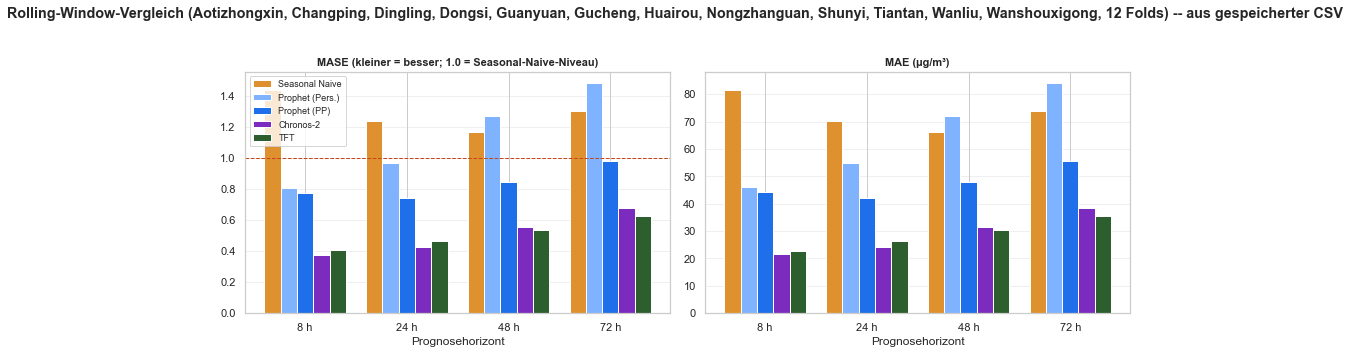

In [16]:
# Reproduzierbarer Vergleichsplot -- nur aus CSV, kein Modell-Lauf noetig.
agg = pd.read_csv(Path("../data/ergebnis_modellvergleich_rolling.csv"))
agg = (agg.groupby(["Horizont", "Modell"])[["MASE", "MAE"]].mean().reset_index())

reihenfolge = ["Seasonal Naive", "Prophet (Pers.)", "Prophet (PP)", "Chronos-2", "TFT"]
modelle = [m for m in reihenfolge if m in agg["Modell"].unique()]
h_labels = [f"{b} h" for b in HORIZONTE]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(h_labels)); w = 0.8 / max(len(modelle), 1)
for ax, metric, titel in zip(axes, ["MASE", "MAE"],
                             ["MASE (kleiner = besser; 1.0 = Seasonal-Naive-Niveau)", "MAE (µg/m³)"]):
    for k, m in enumerate(modelle):
        d = agg[agg["Modell"] == m].set_index("Horizont").reindex(h_labels)[metric].values
        ax.bar(x + (k - (len(modelle) - 1) / 2) * w, d, w, label=m,
               color=FARBEN_MODELLE.get(m, SLATE))
    if metric == "MASE":
        ax.axhline(1.0, color=RUST, ls="--", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(h_labels); ax.set_xlabel("Prognosehorizont")
    ax.set_title(titel, fontsize=11, fontweight="bold"); ax.grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=9)
fig.suptitle(f"Rolling-Window-Vergleich ({', '.join(STATIONEN_VERGLEICH)}, "
             f"{len(fold_start_daten)} Folds) -- aus gespeicherter CSV", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
AUSGABE_PNG = Path("../grafiken/vergleich_rolling_notebook.png")
fig.savefig(AUSGABE_PNG, dpi=130, bbox_inches="tight")
print(f"Plot gespeichert: {AUSGABE_PNG}")
plt.show()

### Auswertung: Durchschnitt über alle Folds, MASE-Verteilung je Horizont

In [17]:
print("Durchschnitt ueber alle Folds & Stationen:")
print(tabelle_rolling.groupby(["Horizont", "Modell"], observed=True)[["MAE", "RMSE", "MASE", "MAPE %"]]
      .mean().round(3).to_string())

print("\nDurchschnitt je Station:")
print(tabelle_rolling.groupby(["Station", "Horizont", "Modell"], observed=True)[["MAE", "MASE"]]
      .mean().round(3).to_string())

Durchschnitt ueber alle Folds & Stationen:
                             MAE    RMSE   MASE   MAPE %
Horizont Modell                                         
8 h      Seasonal Naive   81.576  90.094  1.438  395.352
         Prophet (Pers.)  46.110  49.858  0.806  123.154
         Prophet (PP)     44.259  49.152  0.772   74.636
         Chronos-2        21.466  25.226  0.373   55.979
         TFT              22.889  26.936  0.405   58.345
24 h     Seasonal Naive   70.232  82.905  1.240  288.870
         Prophet (Pers.)  54.858  62.913  0.966  215.714
         Prophet (PP)     42.101  50.422  0.740   88.556
         Chronos-2        24.127  31.456  0.424   67.934
         TFT              26.215  33.674  0.464   65.161
48 h     Seasonal Naive   66.298  82.034  1.169  206.218
         Prophet (Pers.)  72.078  83.226  1.270  251.401
         Prophet (PP)     47.887  57.786  0.842   93.829
         Chronos-2        31.591  41.442  0.554   83.981
         TFT              30.354  39.945  0.5

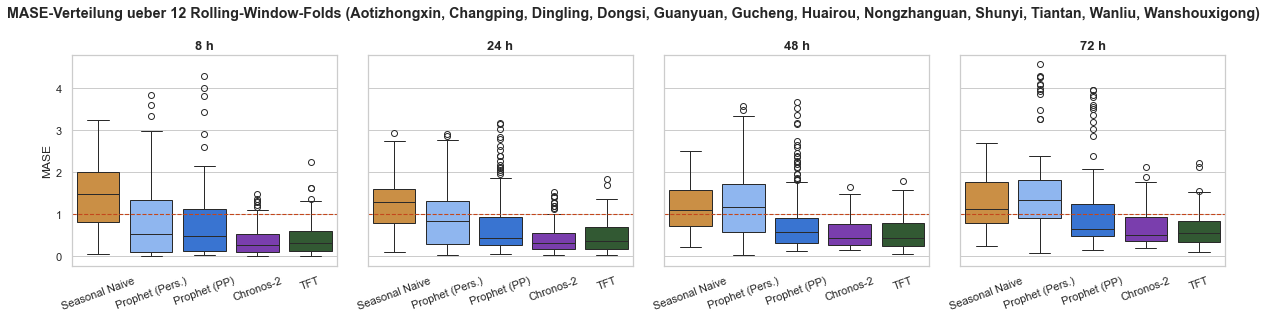

In [18]:
fig, axes = plt.subplots(1, len(HORIZONTE), figsize=(4.2 * len(HORIZONTE), 4.5), sharey=True)
for ax, b in zip(axes, HORIZONTE):
    w = tabelle_rolling[tabelle_rolling["Horizont"] == f"{b} h"]
    ordnung = [m for m in MODELL_ORDER if m in set(w["Modell"])]
    sns.boxplot(data=w, x="Modell", y="MASE", ax=ax, order=ordnung,
               palette=[FARBEN_MODELLE.get(m, SLATE) for m in ordnung])
    ax.axhline(1.0, color=RUST, ls="--", lw=1.1)
    ax.set_title(f"{b} h"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
plt.suptitle(f"MASE-Verteilung ueber {len(fold_start_daten)} Rolling-Window-Folds "
            f"({', '.join(STATIONEN_VERGLEICH)})", fontweight="bold")
plt.tight_layout()
plt.savefig("../grafiken/mase_boxplots_rolling.png", dpi=130, bbox_inches="tight")
plt.show()

### Beispiel-Fold im Detail (mittlerer Fold, erste Station)

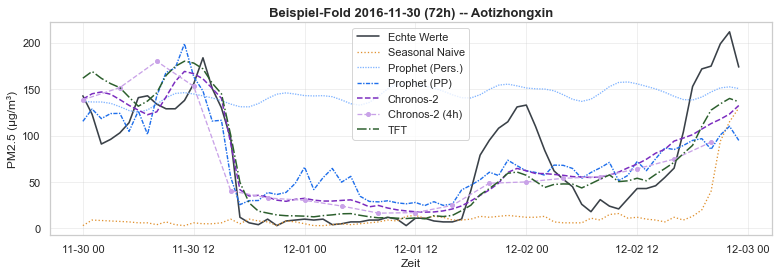

In [19]:
beispiel_fold = fold_start_daten[len(fold_start_daten) // 2]
beispiel_station = STATIONEN_VERGLEICH[0]
beispiel_out = vorhersagen_rolling[(beispiel_fold, beispiel_station)]
beispiel_out_zusatz = vorhersagen_rolling_zusatz[(beispiel_fold, beispiel_station)]
spalte_zusatz = f"yhat_chronos_{AGG_STUNDEN_CHRONOS_ZUSATZ}h"

plt.figure(figsize=(11, 4))
plt.plot(beispiel_out["ds"], beispiel_out["y"], color=SLATE, lw=1.6, label="Echte Werte")
plt.plot(beispiel_out["ds"], beispiel_out["yhat_naive"], color=AMBER, lw=1.3, ls=":", label="Seasonal Naive")
plt.plot(beispiel_out["ds"], beispiel_out["yhat_prophet_pers"], color=FARBEN_MODELLE["Prophet (Pers.)"], lw=1.3, ls=(0, (1, 1)), label="Prophet (Pers.)")
plt.plot(beispiel_out["ds"], beispiel_out["yhat_prophet_pp"], color=FARBEN_MODELLE["Prophet (PP)"], lw=1.4, ls=(0, (3, 1, 1, 1)), label="Prophet (PP)")
plt.plot(beispiel_out["ds"], beispiel_out["yhat_chronos"], color=CHRONOSFARBE, lw=1.5, ls="--", label="Chronos-2")
plt.plot(beispiel_out_zusatz["ds"], beispiel_out_zusatz[spalte_zusatz], color=CHRONOSFARBE_4H, lw=1.3, ls="--",
         marker="o", markersize=4, label=f"Chronos-2 ({AGG_STUNDEN_CHRONOS_ZUSATZ}h)")
plt.plot(beispiel_out["ds"], beispiel_out["yhat_tft"], color=MOSS, lw=1.5, ls="-.", label="TFT")
plt.title(f"Beispiel-Fold {beispiel_fold.date()} ({H_MAX}h) -- {beispiel_station}")
plt.xlabel("Zeit"); plt.ylabel("PM2.5 (\u00b5g/m\u00b3)")
plt.legend(loc="best"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"../grafiken/beispiel_fold_{beispiel_fold.date()}_{beispiel_station}.png", dpi=130, bbox_inches="tight")
plt.show()

## 10. Statistische Signifikanz: Ist der Unterschied bedeutsam?

Mittelwerte allein sagen nicht, ob ein Vorsprung *echt* ist oder nur Zufall der Fold-Auswahl. Hier ein **paarweiser Vergleich** auf den einzelnen (Fold, Station)-Einheiten: je Horizont die MASE-Differenz Δ = MASE(a) − MASE(b) (Δ < 0 → *a* besser), getestet mit dem verteilungsfreien **Wilcoxon-Vorzeichen-Rang-Test** (gepaarter t-Test als Ergänzung), dazu die **Trefferquote** (Anteil der Fälle, in denen *a* besser ist).

> ⚠️ Die (Fold, Station)-Einheiten sind nicht völlig unabhängig (dieselbe Station über Folds bzw. dasselbe Fenster über Stationen sind korreliert) — die p-Werte sind daher **indikativ**, kein strenger Beweis. Für die Frage „Chronos-2 vs. TFT — echter Unterschied?" genügt das.

In [20]:
from scipy import stats

def paarvergleich_horizont(tab, modell_a, modell_b, metrik="MASE"):
    """Paarweiser Vergleich zweier Modelle je Horizont auf den (Fold, Station)-Einheiten.
    Delta = metrik(a) - metrik(b); Delta < 0 => Modell a hat den kleineren Fehler (besser).
    Wilcoxon-Vorzeichen-Rang-Test (verteilungsfrei) + gepaarter t-Test, plus Trefferquote."""
    zeilen = []
    for h in [f"{b} h" for b in HORIZONTE]:
        s = tab[tab["Horizont"] == h]
        pa = s[s["Modell"] == modell_a].set_index(["Fold", "Station"])[metrik]
        pb = s[s["Modell"] == modell_b].set_index(["Fold", "Station"])[metrik]
        paar = pd.concat([pa, pb], axis=1, keys=["a", "b"]).dropna()
        diff = paar["a"] - paar["b"]
        n = len(diff)
        winrate = float((diff < 0).mean()) if n else float("nan")
        wp = stats.wilcoxon(diff).pvalue if (n > 0 and diff.abs().sum() > 0) else float("nan")
        tp = stats.ttest_rel(paar["a"], paar["b"]).pvalue if n > 1 else float("nan")
        zeilen.append({"Horizont": h, "n": n,
                       f"Δ{metrik} (a−b)": round(diff.mean(), 3) if n else float("nan"),
                       f"{modell_a} besser %": round(100 * winrate) if n else float("nan"),
                       "p (Wilcoxon)": round(wp, 3), "p (t-Test)": round(tp, 3)})
    return pd.DataFrame(zeilen)

for a, b in [("TFT", "Chronos-2"), ("TFT", "Prophet (PP)"), ("Chronos-2", "Prophet (PP)")]:
    print(f"\n=== {a} vs. {b}   (Δ<0 → {a} besser) ===")
    print(paarvergleich_horizont(tabelle_rolling, a, b).to_string(index=False))


=== TFT vs. Chronos-2   (Δ<0 → TFT besser) ===
Horizont   n  ΔMASE (a−b)  TFT besser %  p (Wilcoxon)  p (t-Test)
     8 h 144        0.031            43         0.111       0.238
    24 h 144        0.040            51         0.162       0.054
    48 h 144       -0.017            57         0.247       0.455
    72 h 144       -0.049            61         0.006       0.077

=== TFT vs. Prophet (PP)   (Δ<0 → TFT besser) ===
Horizont   n  ΔMASE (a−b)  TFT besser %  p (Wilcoxon)  p (t-Test)
     8 h 144       -0.367            81           0.0         0.0
    24 h 144       -0.275            81           0.0         0.0
    48 h 144       -0.305            78           0.0         0.0
    72 h 144       -0.351            79           0.0         0.0

=== Chronos-2 vs. Prophet (PP)   (Δ<0 → Chronos-2 besser) ===
Horizont   n  ΔMASE (a−b)  Chronos-2 besser %  p (Wilcoxon)  p (t-Test)
     8 h 144       -0.399                  85           0.0         0.0
    24 h 144       -0.316         

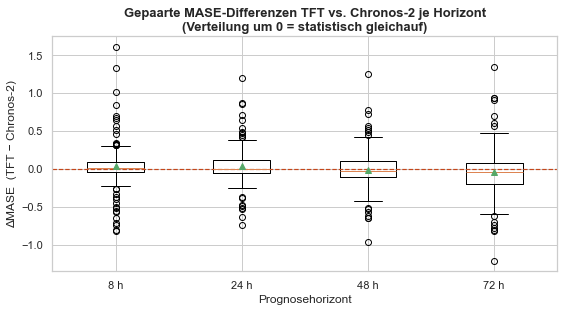

In [21]:
# Visualisierung: gepaarte MASE-Differenzen TFT − Chronos-2 je Horizont (Verteilung um 0)
_paare, _labels = [], [f"{b} h" for b in HORIZONTE]
for h in _labels:
    s = tabelle_rolling[tabelle_rolling["Horizont"] == h]
    pa = s[s["Modell"] == "TFT"].set_index(["Fold", "Station"])["MASE"]
    pb = s[s["Modell"] == "Chronos-2"].set_index(["Fold", "Station"])["MASE"]
    _paare.append((pa - pb).dropna().values)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot(_paare, labels=_labels, showmeans=True)
ax.axhline(0, color=RUST, ls="--", lw=1.2)
ax.set_ylabel("ΔMASE  (TFT − Chronos-2)"); ax.set_xlabel("Prognosehorizont")
ax.set_title("Gepaarte MASE-Differenzen TFT vs. Chronos-2 je Horizont\n"
             "(Verteilung um 0 = statistisch gleichauf)", fontweight="bold")
plt.tight_layout()
plt.savefig("../grafiken/signifikanz_tft_vs_chronos.png", dpi=130, bbox_inches="tight")
plt.show()

> **Lesart:** Liegt Δ nahe 0, ist die Trefferquote ~50 % und der p-Wert groß, sind die beiden Modelle **statistisch gleichauf** — kein belastbarer Unterschied. Erfahrungsgemäß gilt das hier für **TFT vs. Chronos-2**; beide schlagen **Prophet (PP)** dagegen klar (kleine p-Werte, Trefferquote deutlich > 50 %). Fürs Deck also „Chronos-2 und TFT gleichauf an der Spitze" statt „TFT ist das beste Modell".

## 11. Prophet-Komponenten: Interpretierbarkeit

Prophets Stärke gegenüber den „Blackbox"-Modellen (Chronos-2, TFT): die Vorhersage lässt sich in **verständliche Bausteine** zerlegen. `plot_components()` zeigt für eine Station den **Trend**, die **Feiertage** (u. a. den Frühlingsfest-Ausschlag), den **Wochengang**, den **Jahresgang** (Heizperiode Winter ↑ / Sommer ↓), den **Tagesgang** (Abend-Peak / Morgentief) und den kombinierten Beitrag der **Wetter-Regressoren**.

> Zielgröße ist `log1p(PM2.5)` (wie im Vergleich) — die Komponenten sind additiv auf der Log-Skala. Ein Fit auf der vollen Historie dauert ~20–40 s.

20:51:50 - cmdstanpy - INFO - Chain [1] start processing
20:52:15 - cmdstanpy - INFO - Chain [1] done processing


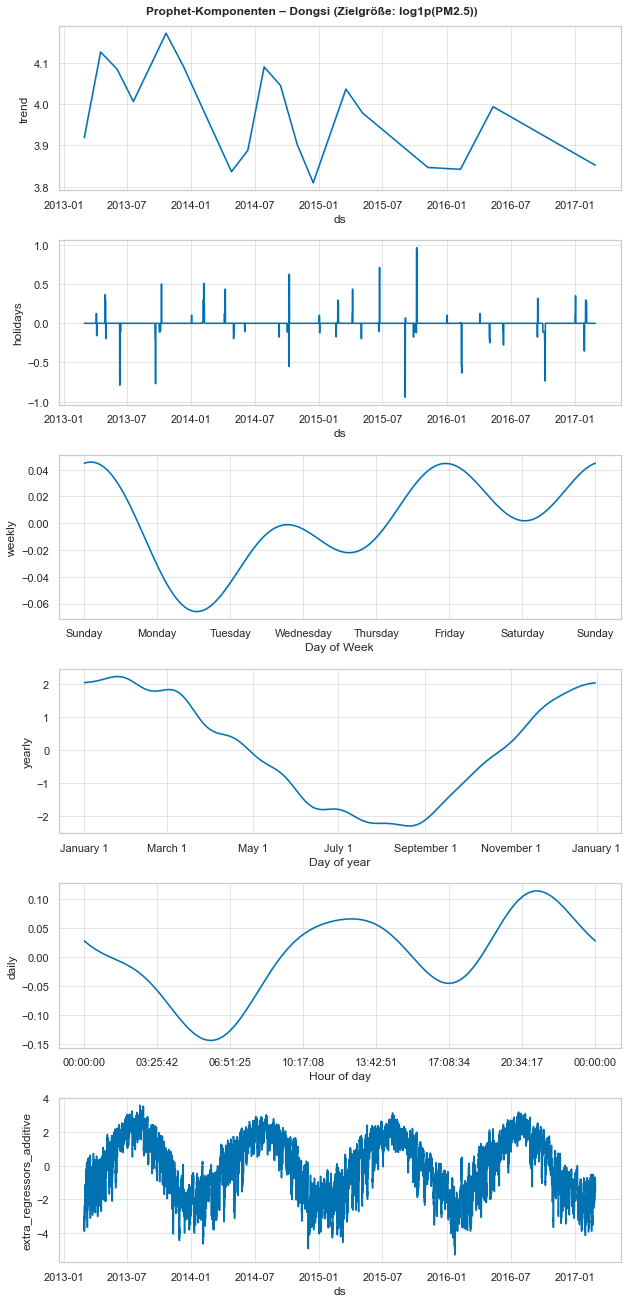

Prophet-Komponenten fuer Dongsi gespeichert.


In [22]:
# Prophet-Komponenten fuer eine Beispielstation (einmaliger Fit auf voller Historie bis Testende).
KOMPONENTEN_STATION = "Dongsi" if "Dongsi" in ALLE_STATIONEN else ALLE_STATIONEN[0]

_g_komp  = _prophet_daten(KOMPONENTEN_STATION)
_tr_komp = _g_komp[_g_komp["ds"] < pd.Timestamp(ROLLING_ENDE)].copy()
_tr_komp["y"] = np.log1p(_tr_komp["y"])

_m_komp = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
_m_komp.add_country_holidays(country_name="CN")
for r in PROPHET_REGRESSOREN:
    _m_komp.add_regressor(r)
_m_komp.fit(_tr_komp[["ds", "y"] + PROPHET_REGRESSOREN])

_fc_komp = _m_komp.predict(_tr_komp[["ds"] + PROPHET_REGRESSOREN])
fig_komp = _m_komp.plot_components(_fc_komp)
fig_komp.suptitle(f"Prophet-Komponenten – {KOMPONENTEN_STATION} (Zielgröße: log1p(PM2.5))",
                  y=1.005, fontsize=12, fontweight="bold")
fig_komp.savefig(f"../grafiken/prophet_komponenten_{KOMPONENTEN_STATION}.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Prophet-Komponenten fuer {KOMPONENTEN_STATION} gespeichert.")